In [1]:
import pandas as pd
from pathlib import Path

csv_path = Path("..") / "part4" / "results" / "4_1" / "results2.csv"
df = pd.read_csv(csv_path)
df.head()

,cores,p95,qps,target,cpu_utilization,run
0,1,410.0,5029.0,5000,20.6,1
1,1,474.7,15043.5,15000,45.3,1
2,1,520.7,25062.0,25000,62.3,1
3,1,543.0,35018.5,35000,68.8,1
4,1,589.7,45058.0,45000,78.0,1


In [2]:
# Resolve column names case-insensitively and verify
cols_lower = {c.lower().strip(): c for c in df.columns}
cores_col = cols_lower.get("cores")
target_col = cols_lower.get("target")
p95_col = cols_lower.get("p95")
qps_col = cols_lower.get("qps")
cpu_utilization_col = cols_lower.get("cpu_utilization")
missing = [
    name for name, col in {
        "cores": cores_col,
        "target": target_col,
        "p95": p95_col,
        "qps": qps_col,
        "cpu_utilization": cpu_utilization_col,
    }.items() if col is None
]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

# Compute mean and std for p95 and qps grouped by threads, cores, and target
df_grouped_stats = (
    df.groupby([cores_col, target_col], as_index=False)
      .agg(
          avg_p95=(p95_col, "mean"),
          std_p95=(p95_col, "std"),
          avg_qps=(qps_col, "mean"),
          std_qps=(qps_col, "std"),
          avg_cpu_utilization=(cpu_utilization_col, "mean"),
          std_cpu_utilization=(cpu_utilization_col, "std"),
      )
      .sort_values([cores_col, target_col])
)

# Convert p95 stats from microseconds to milliseconds
df_grouped_stats[["avg_p95", "std_p95"]] = df_grouped_stats[["avg_p95", "std_p95"]] / 1000

df_grouped_stats.head()

,cores,target,avg_p95,std_p95,avg_qps,std_qps,avg_cpu_utilization,std_cpu_utilization
0,1,5000,0.414500,0.014292,4978.833333,66.427279,21.933333,2.484619
1,1,15000,0.469767,0.010325,15014.133333,168.876000,43.166667,2.150194
2,1,25000,0.516233,0.004957,25039.833333,19.901842,60.266667,1.795364
3,1,35000,0.549200,0.014994,35009.000000,17.327723,68.733333,1.101514
4,1,45000,0.583033,0.009465,45038.000000,35.510562,76.966667,1.234234


In [67]:
df1 = df_grouped_stats[df_grouped_stats[cores_col] == 1].copy()
df2 = df_grouped_stats[df_grouped_stats[cores_col] == 2].copy()
df3 = df_grouped_stats[df_grouped_stats[cores_col] == 3].copy()

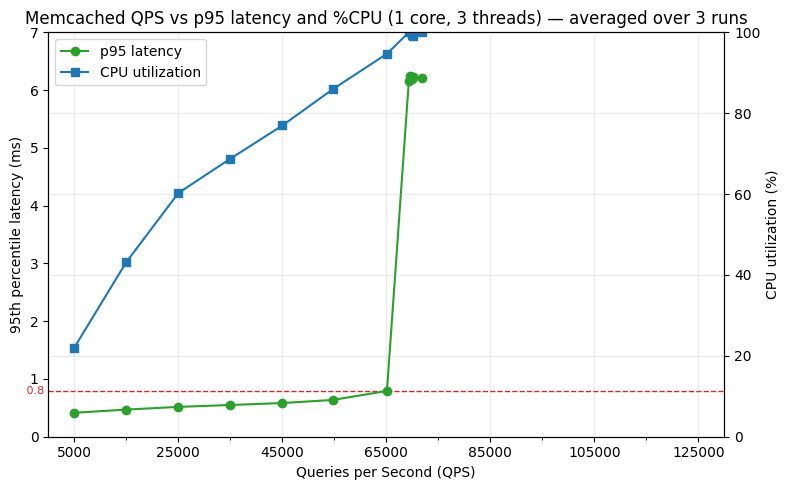

In [91]:
import matplotlib.pyplot as plt

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(df1["avg_qps"], df1["avg_p95"], marker="o", color="tab:green", label="p95 latency", markersize=6)
ax_right.plot(df1["avg_qps"], df1["avg_cpu_utilization"], marker="s", color="tab:blue", label="CPU utilization", markersize=6)
# ax_left.axhline(0.8, color="tab:red", linestyle=":", linewidth=1.5, label="0.8 ms SLO")

ax_left.set_xlim(0, 130000)
ax_left.set_xticks(range(5000, 130001, 20000))
ax_left.xaxis.set_minor_locator(plt.MultipleLocator(10000, 5000))
ax_right.set_ylim(0, 100)
ax_left.set_ylim(0, 7)
ax_left.set_xlabel("Queries per Second (QPS)")
ax_left.set_ylabel("95th percentile latency (ms)")
ax_right.set_ylabel("CPU utilization (%)")
ax_left.set_title(f'Memcached QPS vs 95th percentile latency — averaged over 3 runs per point')

ax_left.axhline(0.8, color='tab:red', linestyle='--', linewidth=1, zorder=0)
ax_left.text(ax_left.get_xlim()[0] - 700, 0.8, ' 0.8', va='center', ha='right', color='tab:red', fontsize=8)

# Combine legends from both axes
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")

ax_left.set_title("Memcached QPS vs p95 latency and %CPU (1 core, 3 threads) — averaged over 3 runs")
ax_left.grid(True, axis="x", alpha=0.25)
# ax_left.grid(True, axis="y", alpha=0.1, linestyle="--")
ax_right.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

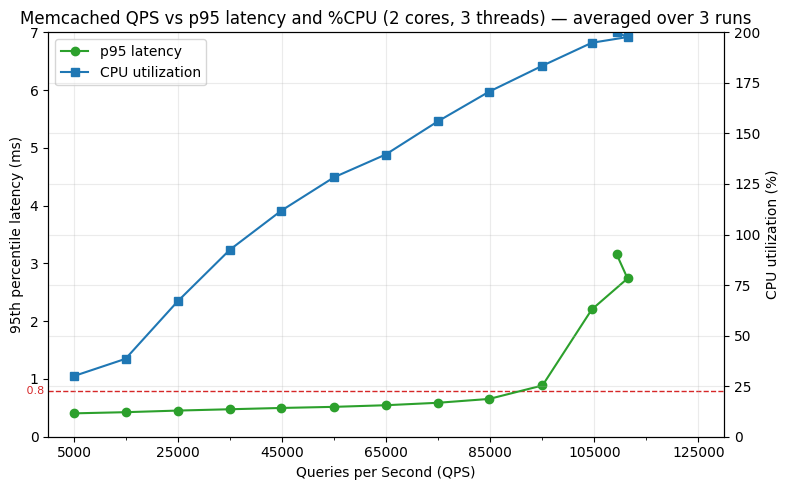

In [88]:
import matplotlib.pyplot as plt

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(df2["avg_qps"], df2["avg_p95"], marker="o", color="tab:green", label="p95 latency", markersize=6)
ax_right.plot(df2["avg_qps"], df2["avg_cpu_utilization"], marker="s", color="tab:blue", label="CPU utilization", markersize=6)
# ax_left.axhline(0.8, color="tab:red", linestyle=":", linewidth=1.5, label="0.8 ms SLO")

ax_left.set_xlim(0, 130000)
ax_left.set_xticks(range(5000, 130001, 20000))
ax_left.xaxis.set_minor_locator(plt.MultipleLocator(10000, 5000))
ax_right.set_ylim(0, 200)
ax_left.set_ylim(0, 7)
ax_left.set_xlabel("Queries per Second (QPS)")
ax_left.set_ylabel("95th percentile latency (ms)")
ax_right.set_ylabel("CPU utilization (%)")
ax_left.set_title(f'Memcached QPS vs 95th percentile latency — averaged over 3 runs per point')

ax_left.axhline(0.8, color='tab:red', linestyle='--', linewidth=1, zorder=0)
ax_left.text(ax_left.get_xlim()[0] - 700, 0.8, ' 0.8', va='center', ha='right', color='tab:red', fontsize=8)

# Combine legends from both axes
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")

ax_left.set_title("Memcached QPS vs p95 latency and %CPU (2 cores, 3 threads) — averaged over 3 runs")
# ax_left.set_title("Memcached QPS vs 95th percentile latency — averaged over 3 runs per point\n (1 core, 3 threads)")
# ax_left.set_title("1 core, 3 threads memcached QPS vs 95th percentile latency\naveraged over 3 runs per point")
ax_left.grid(True, axis="x", alpha=0.25)
# ax_left.grid(True, axis="y", alpha=0.1, linestyle="--")
ax_right.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

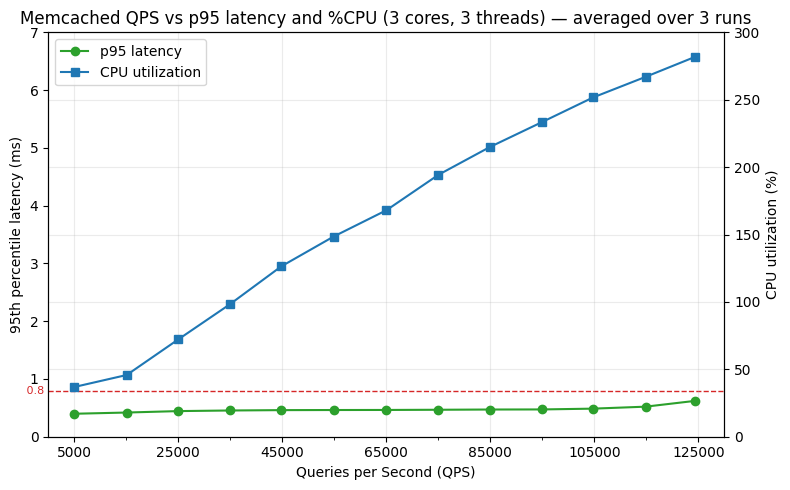

In [90]:
import matplotlib.pyplot as plt

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(df3["avg_qps"], df3["avg_p95"], marker="o", color="tab:green", label="p95 latency", markersize=6)
ax_right.plot(df3["avg_qps"], df3["avg_cpu_utilization"], marker="s", color="tab:blue", label="CPU utilization", markersize=6)
# ax_left.axhline(0.8, color="tab:red", linestyle=":", linewidth=1.5, label="0.8 ms SLO")

ax_left.set_xlim(0, 130000)
ax_left.set_xticks(range(5000, 130001, 20000))
ax_left.xaxis.set_minor_locator(plt.MultipleLocator(10000, 5000))
ax_right.set_ylim(0, 300)
ax_left.set_ylim(0, 7)
ax_left.set_xlabel("Queries per Second (QPS)")
ax_left.set_ylabel("95th percentile latency (ms)")
ax_right.set_ylabel("CPU utilization (%)")
ax_left.set_title(f'Memcached QPS vs 95th percentile latency — averaged over 3 runs per point')

ax_left.axhline(0.8, color='tab:red', linestyle='--', linewidth=1, zorder=0)
ax_left.text(ax_left.get_xlim()[0] - 700, 0.8, ' 0.8', va='center', ha='right', color='tab:red', fontsize=8)

# Combine legends from both axes
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")

ax_left.set_title("Memcached QPS vs p95 latency and %CPU (3 cores, 3 threads) — averaged over 3 runs")
# ax_left.set_title("Memcached QPS vs 95th percentile latency — averaged over 3 runs per point\n (1 core, 3 threads)")
# ax_left.set_title("1 core, 3 threads memcached QPS vs 95th percentile latency\naveraged over 3 runs per point")
ax_left.grid(True, axis="x", alpha=0.25)
# ax_left.grid(True, axis="y", alpha=0.1, linestyle="--")
ax_right.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()